In [1]:
import numpy as np
import matplotlib.pyplot as plt

%cd "C:/Users/mateo/Desktop/polymath/joint training experiments/algorithms/toys"

from toy_algorithms import (
    HIGH_DIM,
    LATENT_DIM,
    TOY_NAMES,
    TOY_CLASSES,
    device,
    make_toy,
    train_algorithm1,
    train_algorithm2,
    train_algorithm3,
    train_algorithm4,
    train_algorithm5,
    evaluate_toy_model,
    plot_toy_losses,
    plot_toy_analysis,
    print_toy_metrics,
)

print("Using:", device)


C:\Users\mateo\Desktop\polymath\joint training experiments\algorithms\toys
Using: cuda


In [5]:
ALGORITHM_NUMBER = 1
ALGORITHM_NAME = "Algorithm 1"
TRAIN_FUNCTION = train_algorithm1

NUM_EPOCHS = 200
TRAIN_SAMPLES = 3000
EVAL_SAMPLES = 2000
BATCH_SIZE = 256
NUM_LANDMARKS = 128
TEMPERATURE = 1.0

LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3
LAMBDA_ADV = 1.0
LAMBDA_L1 = 0.0
VAE_PRETRAIN_EPOCHS = 25

EXTRA_KWARGS = {}


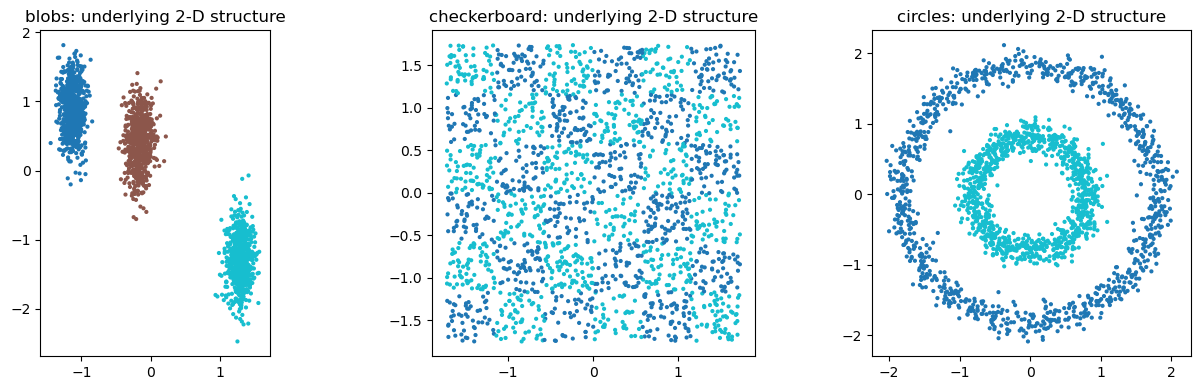

All toy observations have dimension 500.
Temperature: 1.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, toy_name in zip(axes, TOY_NAMES):
    _, labels, points = make_toy(toy_name, 2000, seed=7)
    axis.scatter(points[:, 0], points[:, 1], c=labels, s=4, cmap="tab10")
    axis.set_title(f"{toy_name}: underlying 2-D structure")
    axis.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"All toy observations have dimension {HIGH_DIM}.")
print("Temperature:", TEMPERATURE)


In [7]:
models = {}
histories = {}
evaluations = {}

for toy_name in TOY_NAMES:
    print(f"\n===== {ALGORITHM_NAME}: {toy_name} =====")
    train_x, train_y, _ = make_toy(
        toy_name,
        TRAIN_SAMPLES,
        seed=7,
        high_dim=HIGH_DIM,
    )
    model, history = TRAIN_FUNCTION(
        train_x,
        train_y,
        TOY_CLASSES[toy_name],
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        latent_dim=LATENT_DIM,
        num_landmarks=NUM_LANDMARKS,
        T=TEMPERATURE,
        lambda_kl=LAMBDA_KL,
        lambda_drift=LAMBDA_DRIFT,
        lambda_var=LAMBDA_VAR,
        lambda_cov=LAMBDA_COV,
        lr=1e-3,
        **EXTRA_KWARGS,
    )
    eval_x, eval_y, _ = make_toy(
        toy_name,
        EVAL_SAMPLES,
        seed=700,
        high_dim=HIGH_DIM,
    )
    models[toy_name] = model
    histories[toy_name] = history
    evaluations[toy_name] = evaluate_toy_model(
        model,
        eval_x,
        eval_y,
        TOY_CLASSES[toy_name],
        seed=123,
    )



===== Algorithm 1: blobs =====
Algorithm 1 epoch 001: total=0.37350 recon=0.00847 drift=0.00447
Algorithm 1 epoch 002: total=0.24871 recon=0.00504 drift=0.00059
Algorithm 1 epoch 003: total=0.23807 recon=0.00463 drift=0.00026
Algorithm 1 epoch 010: total=0.29488 recon=0.00379 drift=0.00270
Algorithm 1 epoch 020: total=0.37831 recon=0.00309 drift=0.00554
Algorithm 1 epoch 030: total=0.41409 recon=0.00080 drift=0.00688
Algorithm 1 epoch 040: total=0.44609 recon=0.00064 drift=0.00796
Algorithm 1 epoch 050: total=0.43585 recon=0.00065 drift=0.00773
Algorithm 1 epoch 060: total=0.45452 recon=0.00061 drift=0.00842
Algorithm 1 epoch 070: total=0.45969 recon=0.00060 drift=0.00864
Algorithm 1 epoch 080: total=0.50637 recon=0.00061 drift=0.01019
Algorithm 1 epoch 090: total=0.49435 recon=0.00063 drift=0.00989
Algorithm 1 epoch 100: total=0.50900 recon=0.00065 drift=0.01046
Algorithm 1 epoch 110: total=0.53063 recon=0.00063 drift=0.01124
Algorithm 1 epoch 120: total=0.54219 recon=0.00060 drift=0

In [8]:
# No image metrics or FID are used for the toy models.
# These summaries focus on distribution alignment and latent structure.
print_toy_metrics(evaluations)



===== blobs =====
swd_data: 0.024847
swd_latent: 0.558025
real_latent_std: 0.054383
generated_latent_std: 0.794363
real_latent_tc: 77.886861
generated_latent_tc: 1.109432
real_latent_mig: 0.000286
generated_latent_mig: 0.006515
generated_class_entropy: 1.000000

===== checkerboard =====
swd_data: 0.014362
swd_latent: 0.423076
real_latent_std: 0.070234
generated_latent_std: 0.733813
real_latent_tc: 59.952211
generated_latent_tc: 1.506870
real_latent_mig: 0.027879
generated_latent_mig: 0.000663
generated_class_entropy: 1.000000

===== circles =====
swd_data: 0.014441
swd_latent: 0.458155
real_latent_std: 0.065296
generated_latent_std: 0.758788
real_latent_tc: 57.100897
generated_latent_tc: 1.608789
real_latent_mig: 0.103620
generated_latent_mig: 0.001919
generated_class_entropy: 1.000000


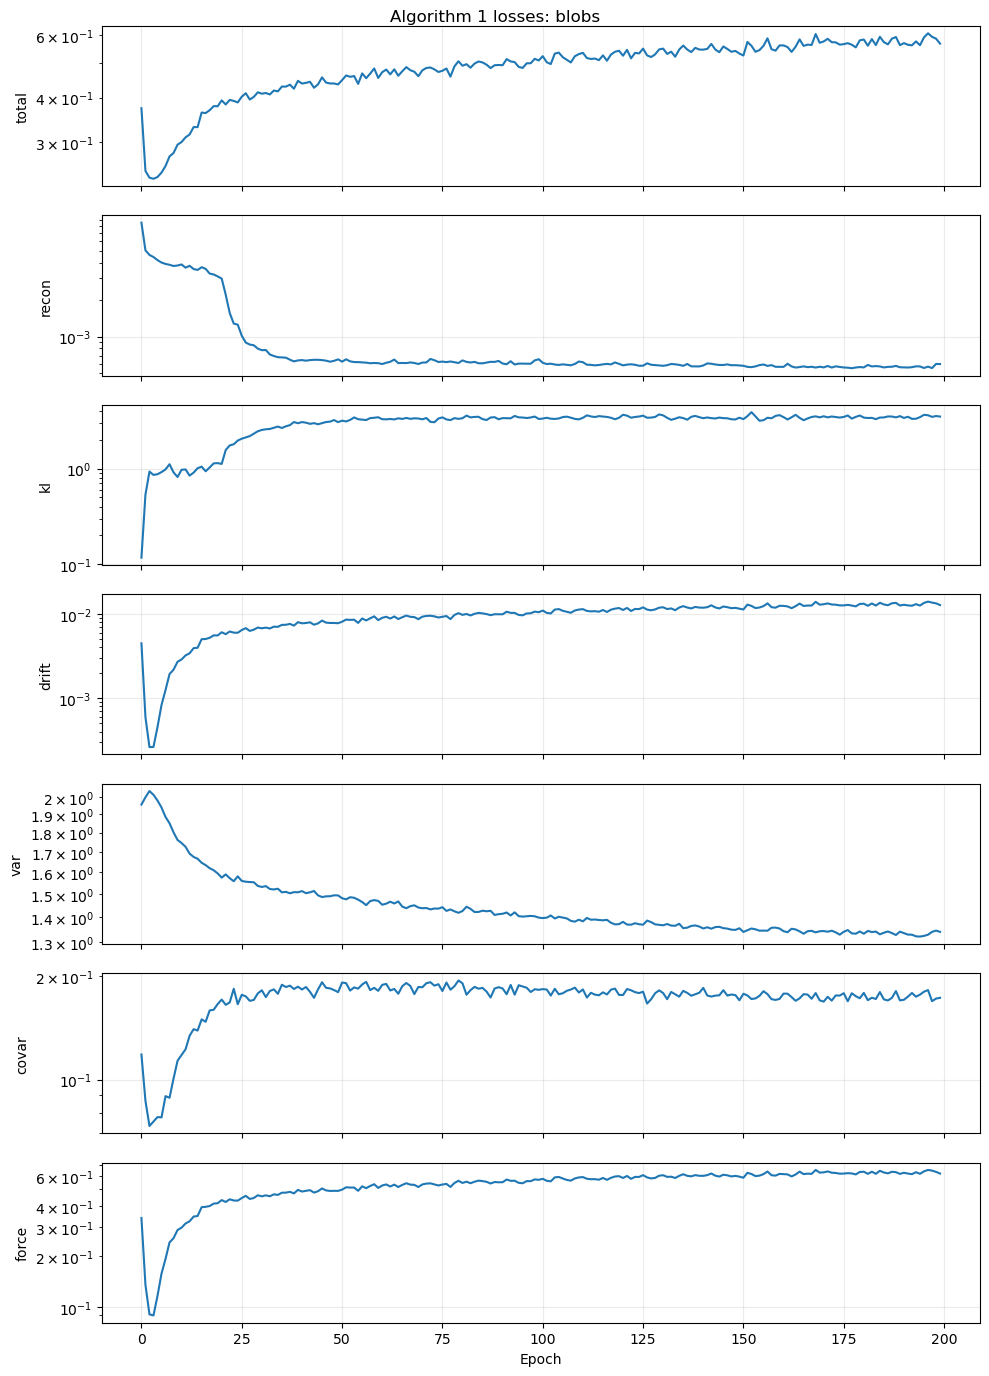

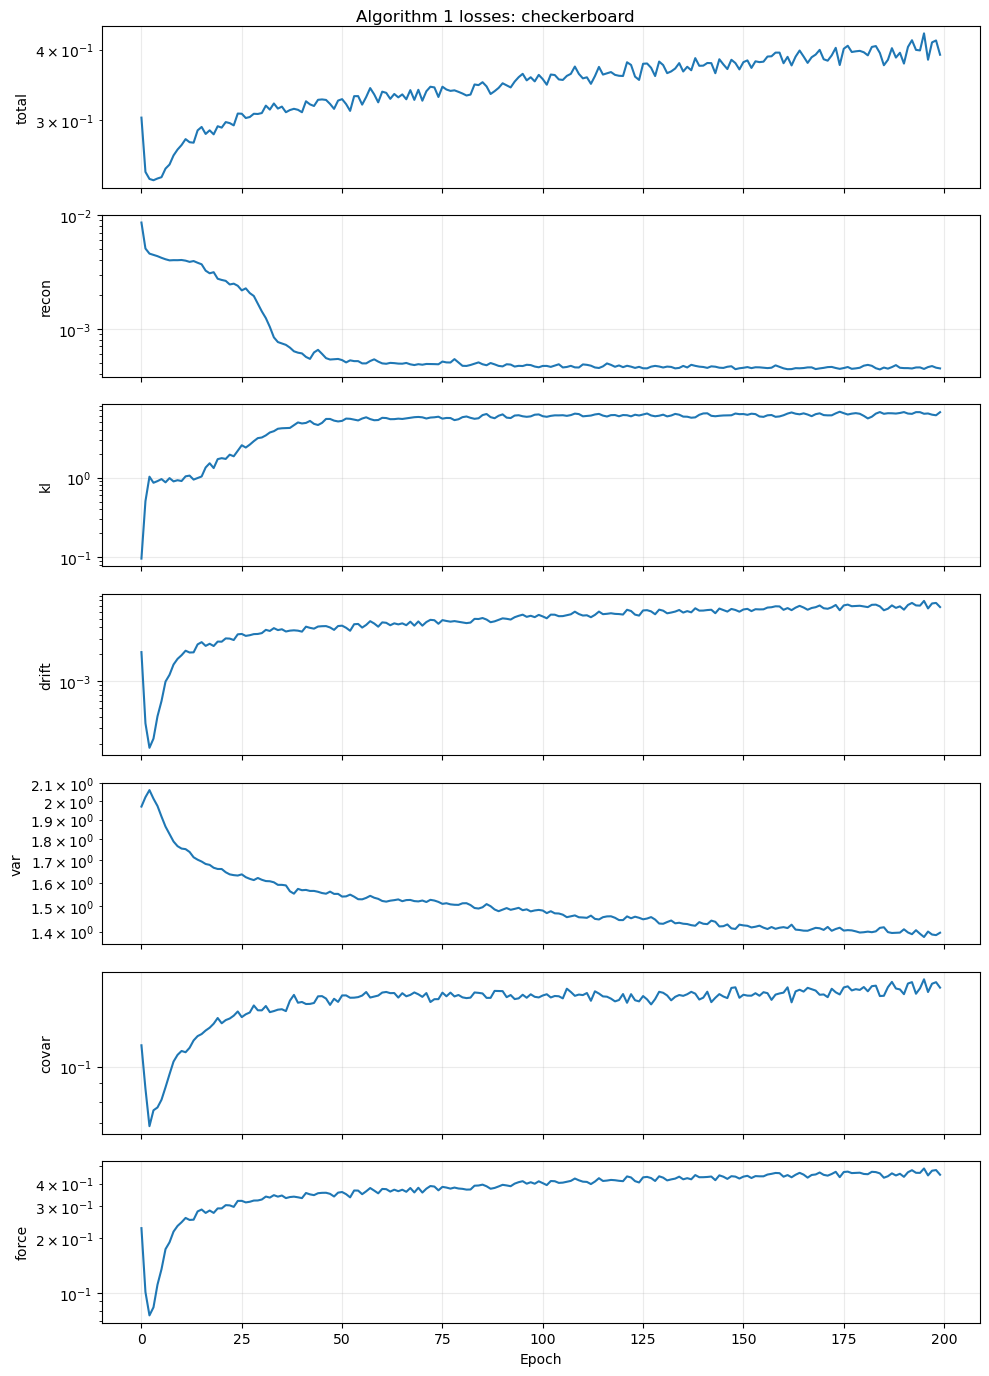

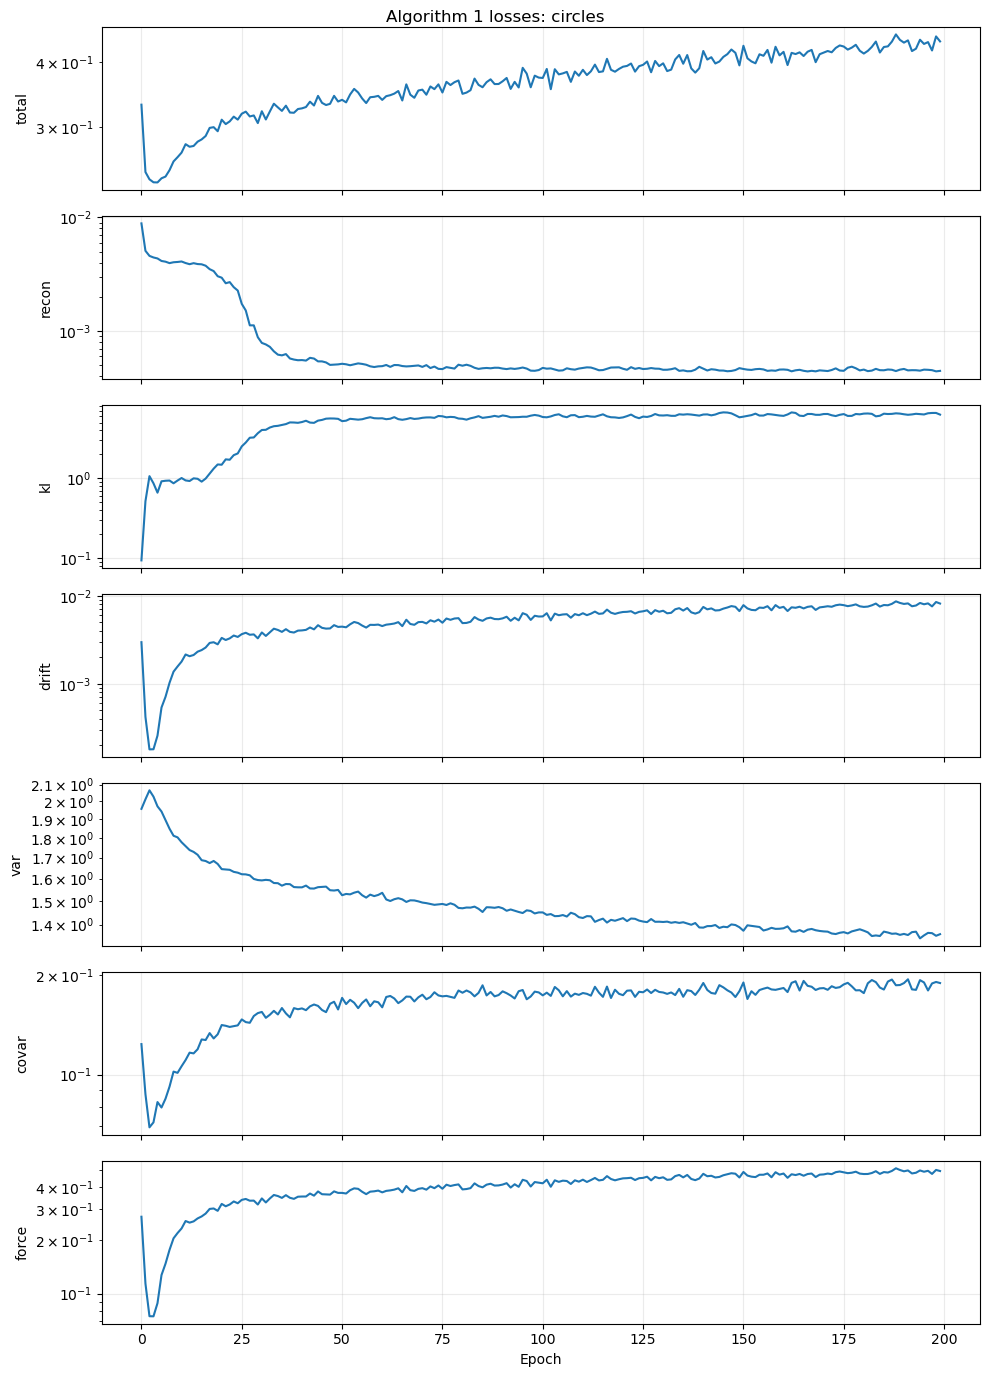

In [9]:
plot_toy_losses(histories, ALGORITHM_NAME)


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


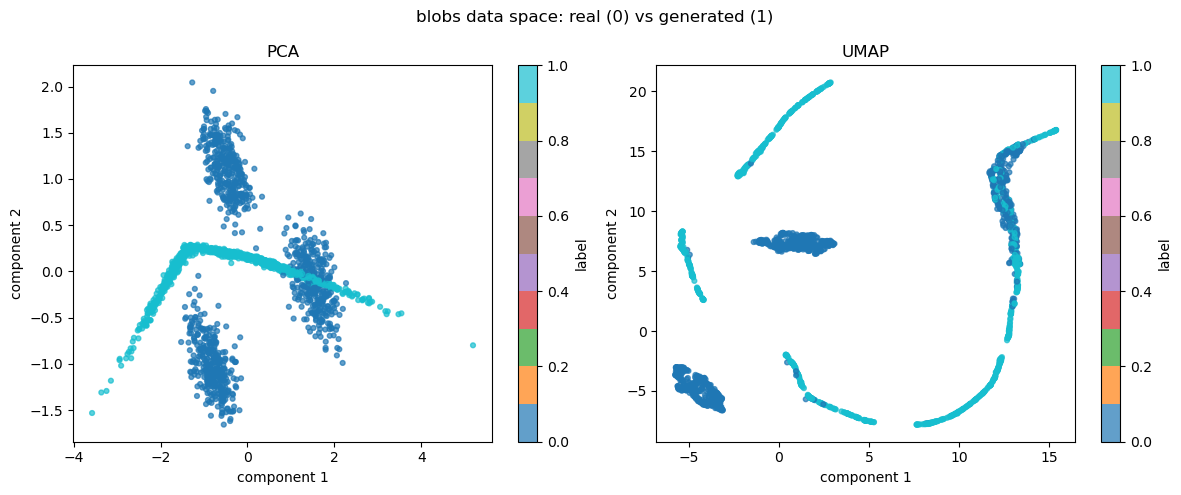

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


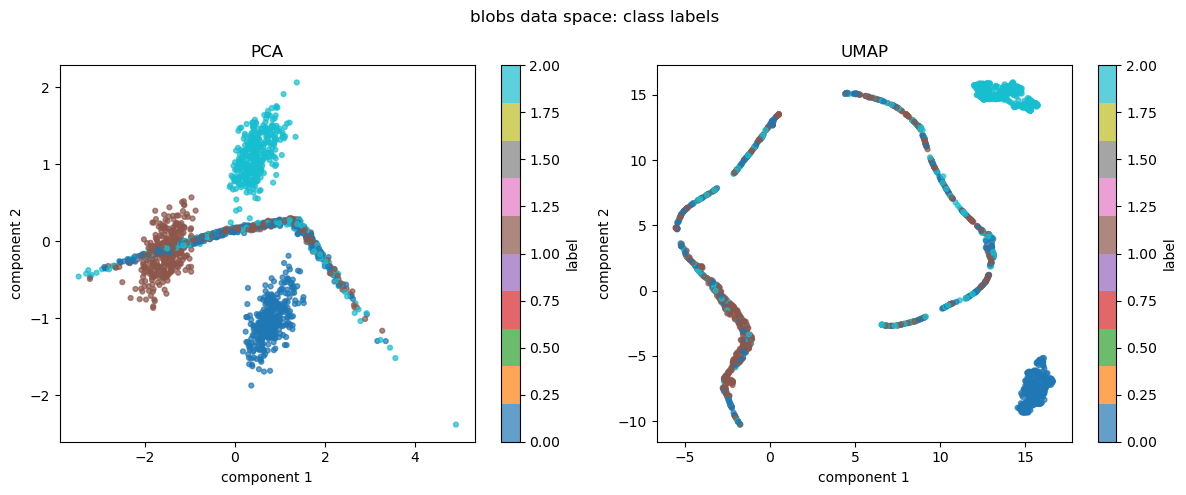

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


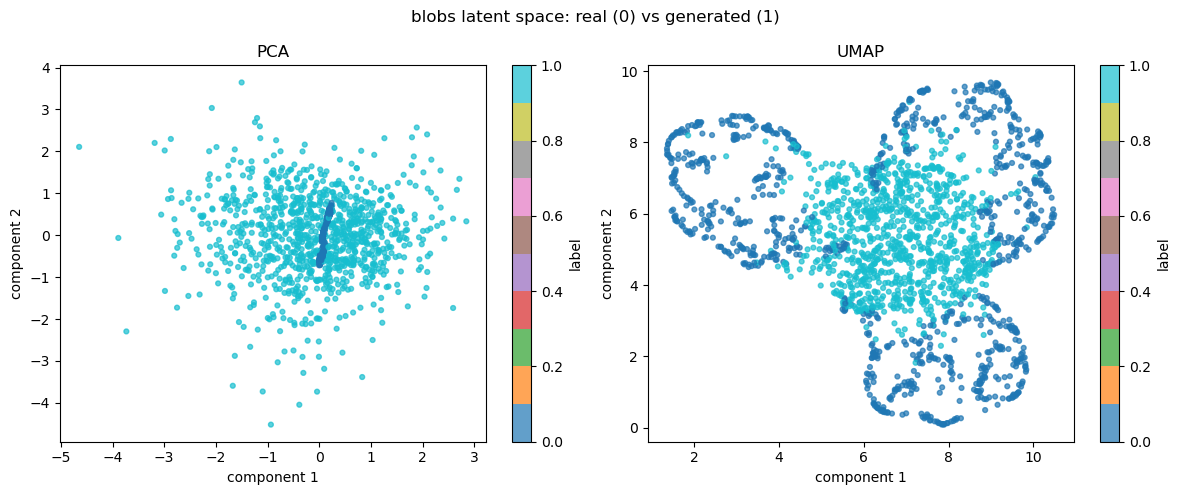

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


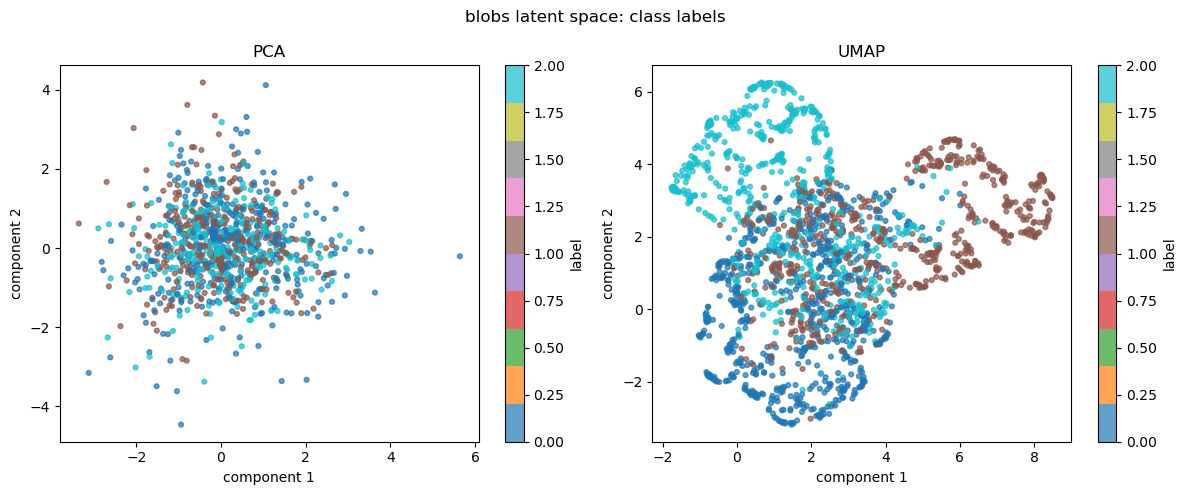

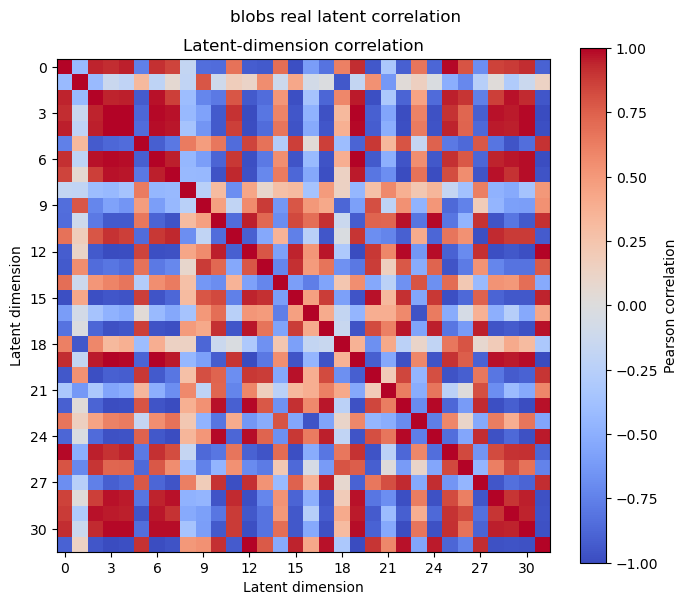

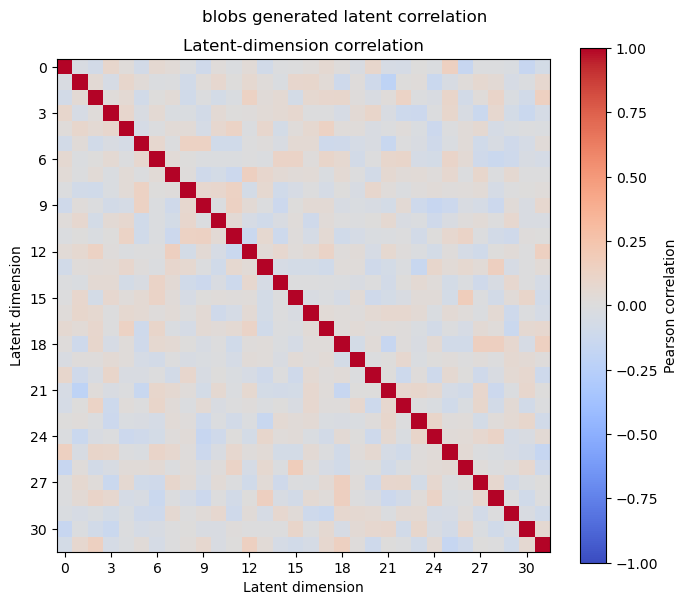

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


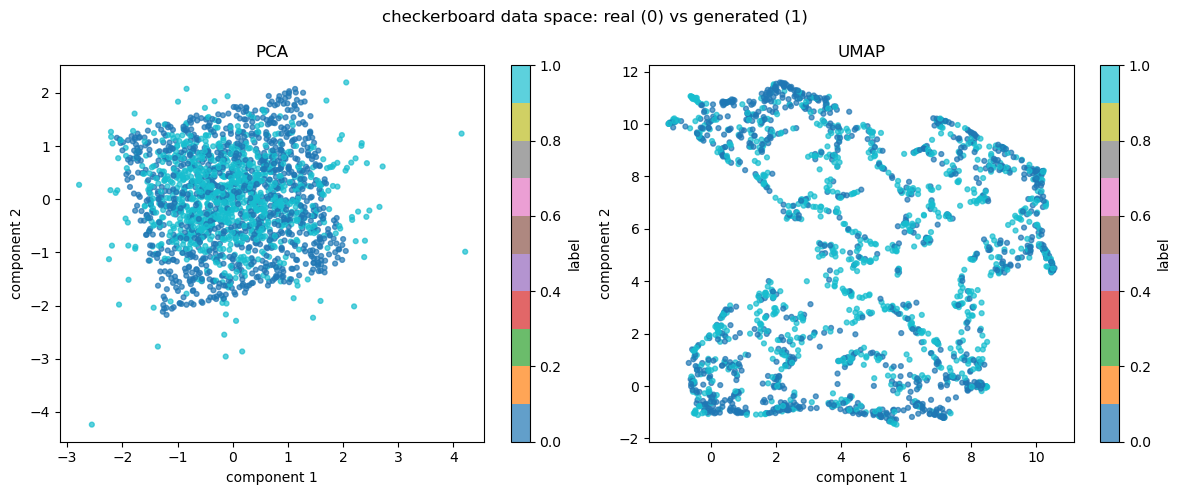

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


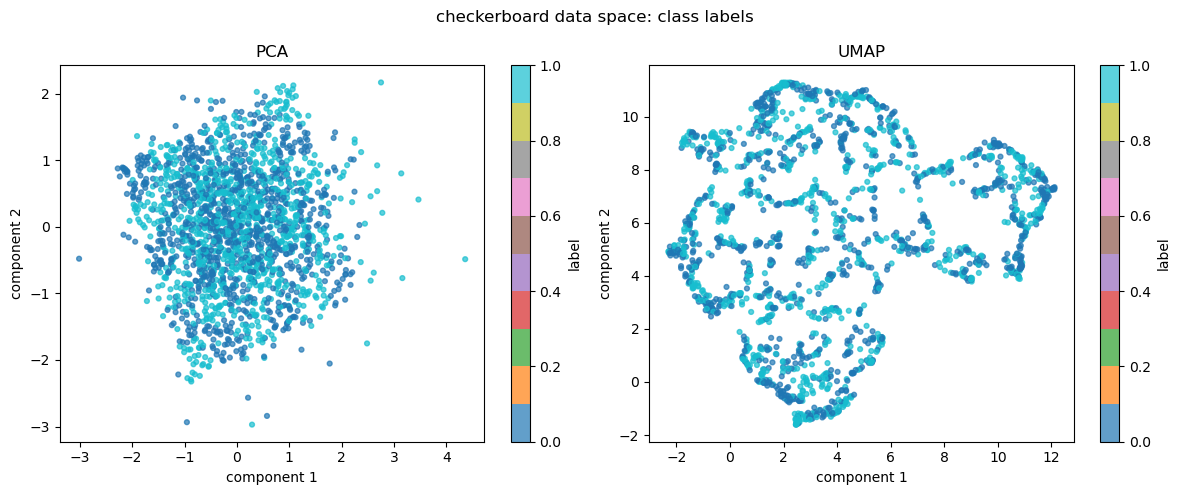

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


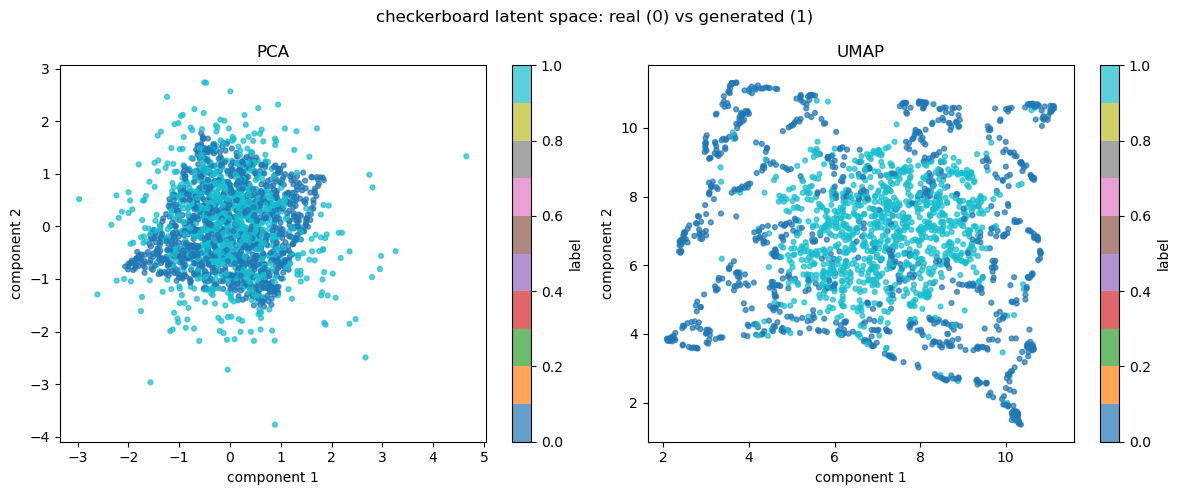

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


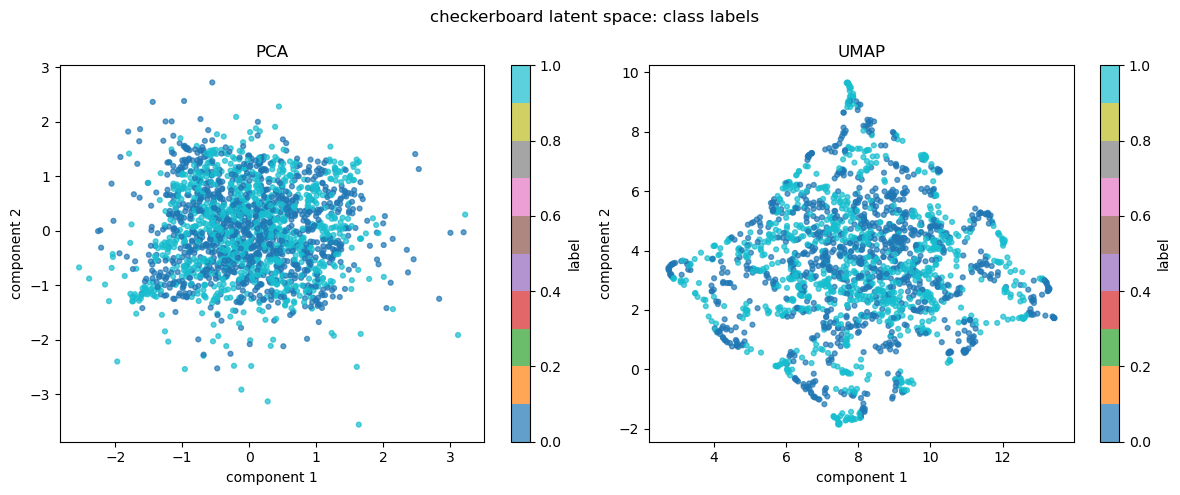

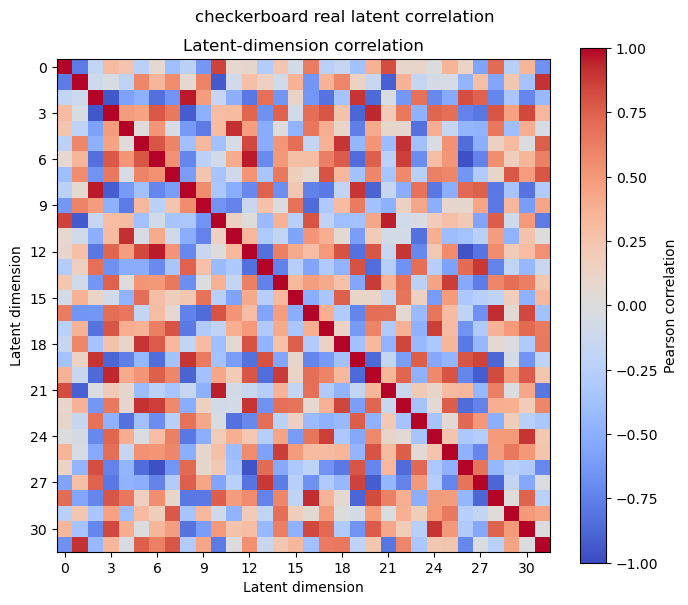

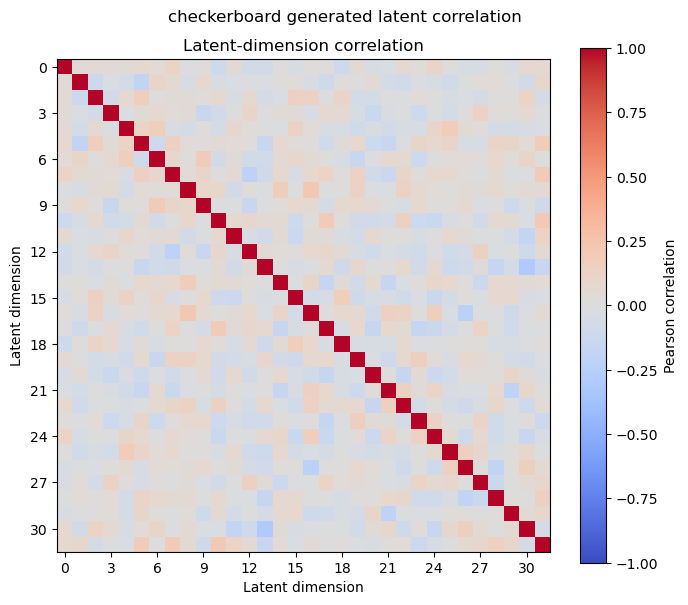

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


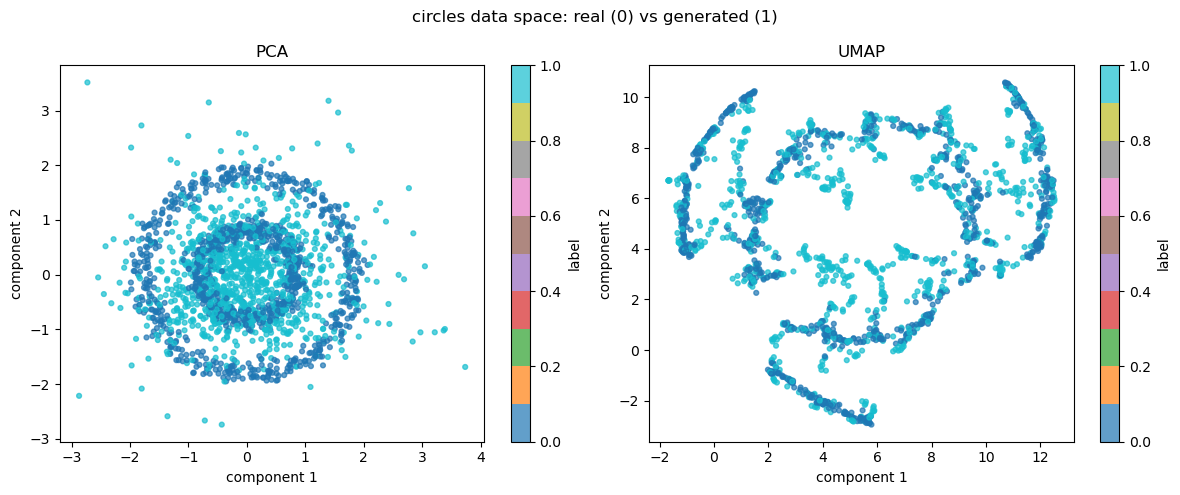

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


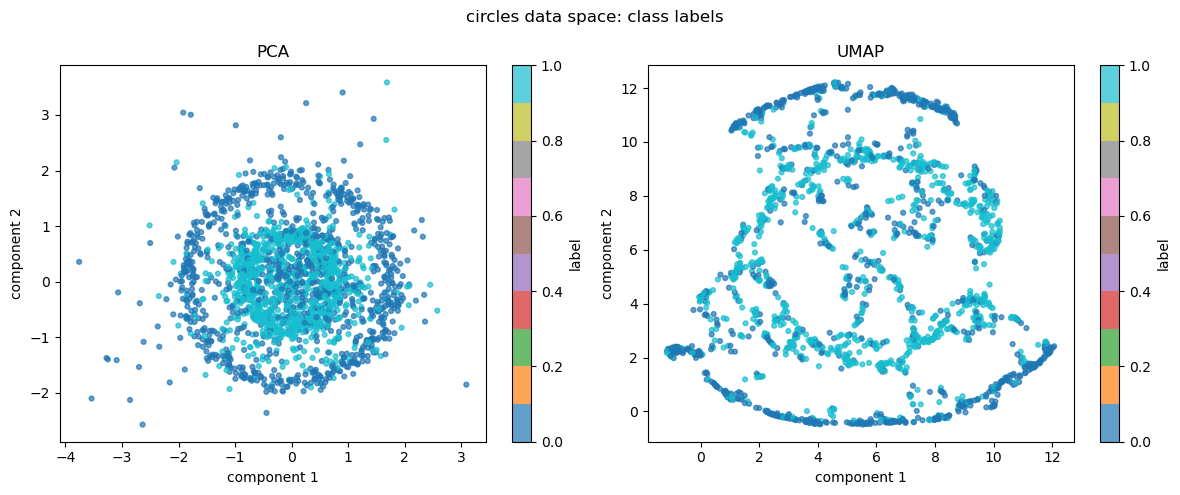

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


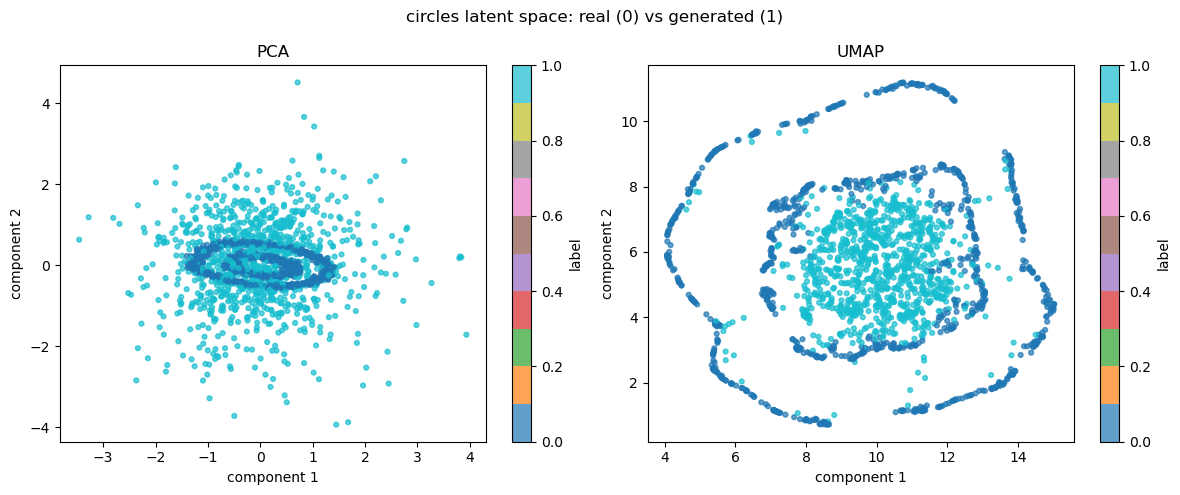

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


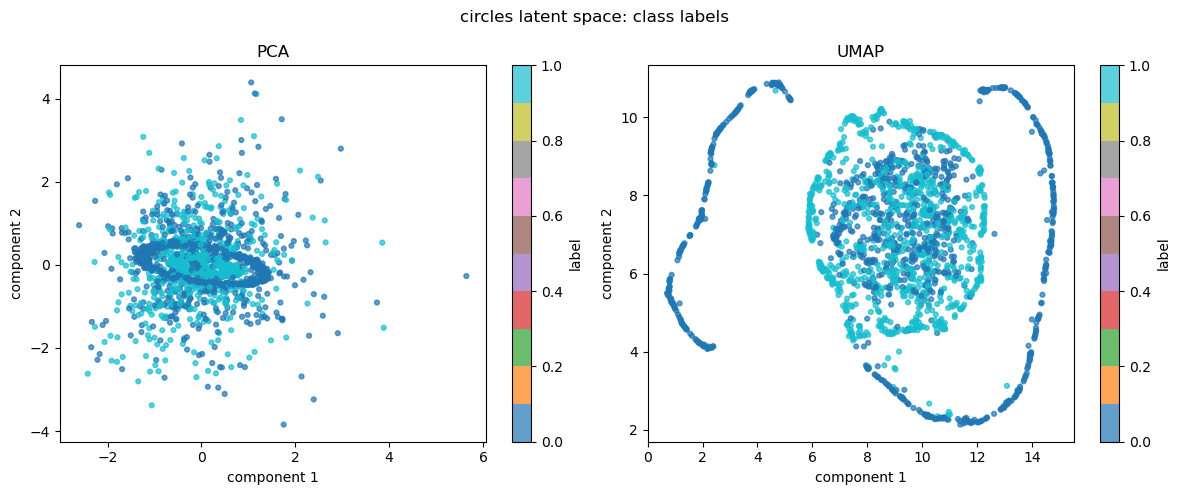

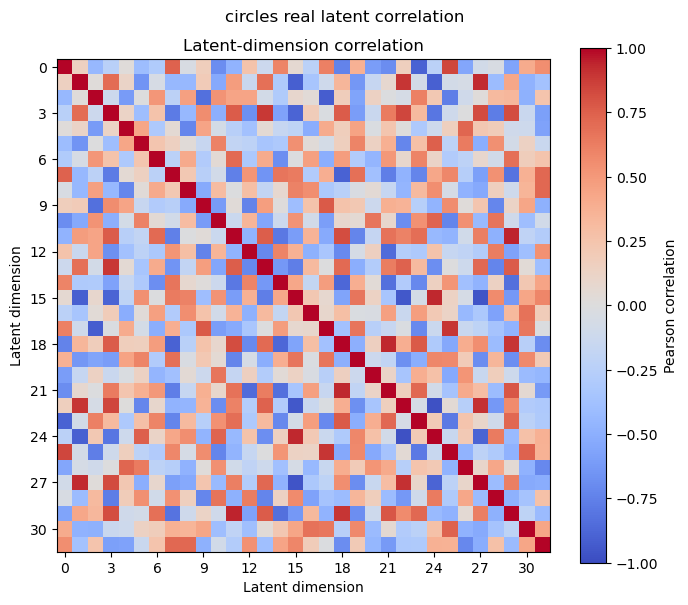

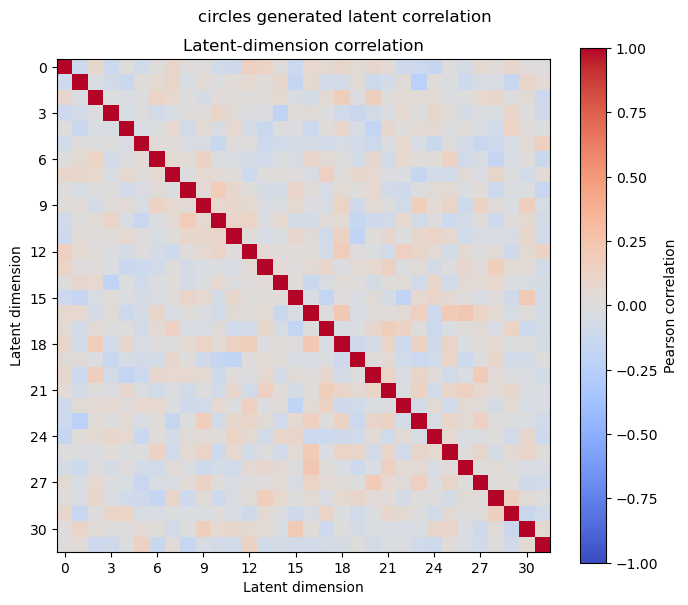

In [10]:
for toy_name in TOY_NAMES:
    plot_toy_analysis(
        evaluations[toy_name],
        toy_name,
        plot_samples=1000,
    )
